# Fase 4 — Modelagem de Tópicos (BERTopic)
**Projeto:** Deriva de Pauta nas Notícias do CNJ

Descoberta não supervisionada da pauta via BERTopic:
`embeddings → UMAP → HDBSCAN → c-TF-IDF`.

Este notebook **apresenta** os artefatos gerados por `src/embed.py` e
`src/topics.py` (toda a computação pesada está nos scripts, para
reprodutibilidade). Reexecute o pipeline com:

```bash
python src/embed.py        # gera data/processed/embeddings.npy
python src/topics.py --sizes 10 15 20
```

### Escolha do modelo de embeddings
`sentence-transformers/paraphrase-multilingual-mpnet-base-v2` (768 dim),
forte em similaridade semântica em pt-BR; custo irrelevante para ~1k docs.
Embeddamos `título + corpo` (título reforça a pauta), `max_seq_length=256`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

eval_df = pd.read_csv(PROC / "topic_eval.csv")
info = pd.read_csv(PROC / "topic_info.csv")
doc_topics = pd.read_parquet(PROC / "doc_topics.parquet")
print("Embeddings:", np.load(PROC / "embeddings.npy").shape)
print("Documentos:", len(doc_topics))
eval_df

Embeddings: (979, 768)
Documentos: 979


,min_topic_size,n_topics,coherence_cv,diversity,outlier_pct
0,10,23,0.6335,0.9217,39.22
1,15,12,0.7192,0.9500,31.15
2,20,10,0.7770,1.0000,29.42


## 1. Seleção de `min_topic_size`

Testamos 3 valores. **Critério de seleção declarado a priori:** maior coerência
**c_v** (desempate: menor % de outliers). Métricas:
- **c_v** (gensim): coerência semântica média dos tópicos.
- **diversity**: fração de termos únicos entre os top-10 de todos os tópicos.
- **outlier_pct**: % de documentos no tópico -1 (ruído bruto do HDBSCAN).

> Observe o *trade-off* real: `min_topic_size` maior → menos tópicos, mais
> coesos (c_v↑) e menos outliers, ao custo de granularidade. Reportamos os três.

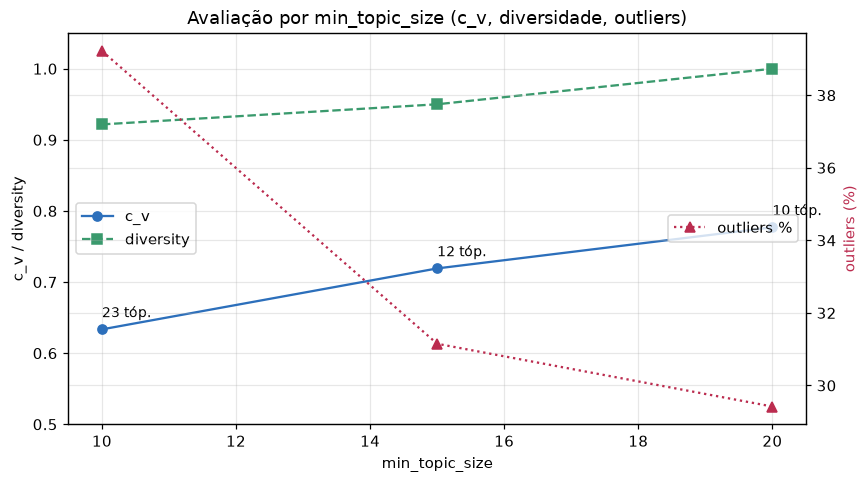

Selecionado: min_topic_size=20 (c_v=0.777, 10 tópicos, outliers brutos=29.42%)


In [2]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(eval_df["min_topic_size"], eval_df["coherence_cv"], "o-",
         color="#2c6fbb", label="c_v")
ax1.plot(eval_df["min_topic_size"], eval_df["diversity"], "s--",
         color="#3a9a6d", label="diversity")
ax1.set_xlabel("min_topic_size"); ax1.set_ylabel("c_v / diversity")
ax1.set_ylim(0.5, 1.05)
ax2 = ax1.twinx()
ax2.plot(eval_df["min_topic_size"], eval_df["outlier_pct"], "^:",
         color="#bb2c4f", label="outliers %")
ax2.set_ylabel("outliers (%)", color="#bb2c4f")
for _, r in eval_df.iterrows():
    ax1.annotate(f"{int(r['n_topics'])} tóp.",
                 (r["min_topic_size"], r["coherence_cv"]),
                 textcoords="offset points", xytext=(0, 8), fontsize=9)
ax1.legend(loc="center left"); ax2.legend(loc="center right")
ax1.set_title("Avaliação por min_topic_size (c_v, diversidade, outliers)")
plt.tight_layout(); plt.savefig(FIG / "07_topic_eval.png"); plt.show()

best = eval_df.dropna(subset=["coherence_cv"]).sort_values(
    ["coherence_cv", "outlier_pct"], ascending=[False, True]).iloc[0]
print(f"Selecionado: min_topic_size={int(best['min_topic_size'])} "
      f"(c_v={best['coherence_cv']}, {int(best['n_topics'])} tópicos, "
      f"outliers brutos={best['outlier_pct']}%)")

## 2. Tópicos descobertos

Tabela tópico → tamanho → termos (c-TF-IDF). Após o ajuste do modelo
selecionado, os outliers foram reatribuídos ao tópico mais próximo
(`reduce_outliers`, estratégia c-TF-IDF) para a análise temporal da Fase 5 — por
isso `Count` aqui reflete a distribuição **após** a redução.

In [3]:
def short(rep, k=8):
    rep = rep.strip("[]").replace("'", "")
    return ", ".join([w.strip() for w in rep.split(",")][:k])

tbl = info[info["Topic"] != -1].copy()
tbl["Termos (top-8)"] = tbl["Representation"].map(short)
tbl = tbl[["Topic", "Count", "Termos (top-8)"]].rename(
    columns={"Topic": "Tópico", "Count": "Nº docs"})
print(tbl.to_string(index=False))

 Tópico  Nº docs                                                                                             Termos (top-8)
      0      179                              atendimentos, itinerante, serviços, trabalho, ação, cidadania, população, rua
      1      152                  conecta, inteligência artificial, artificial, inteligência, dados, ia, superior, soluções
      2      106                               saúde, judicialização, 2025, processos, suplementar, conciliação, ações, sus
      3      139                         direitos humanos, humanos, direitos, corte, fachin, idh, interamericana, corte idh
      4       96       violência, mulheres, mulher, doméstica, violência doméstica, contra, enfrentamento, violência contra
      5       89                      prisional, pena, sistema, pena justa, justa, sistema prisional, penal, socioeducativo
      6       68 crianças, crianças adolescentes, adolescentes, infância, criança, adoção, adolescente, criança adolescente
      7 

### Interpretação (mapeamento para a pauta do CNJ)

Leitura dos termos de cada tópico (rótulos atribuídos manualmente a partir da
representação c-TF-IDF — interpretação, não métrica):

| Tópico | Pauta interpretada |
|---|---|
| 0 | Justiça itinerante, cidadania, atendimento à população (inclusive em situação de rua) |
| 1 | **Conecta / Inteligência Artificial / Justiça 4.0** |
| 2 | Saúde: judicialização, SUS, conciliação |
| 3 | **Direitos humanos / Corte IDH / sistema interamericano** (pres. Fachin) |
| 4 | **Violência doméstica e proteção a mulheres** |
| 5 | **Sistema prisional / Pena Justa / socioeducativo** |
| 6 | Infância e juventude, adoção |
| 7 | Sustentabilidade ambiental, resíduos, carbono |
| 8 | Processos disciplinares, sessões, magistratura |
| 9 | Precatórios, inspeção, corregedoria |

Vários tópicos correspondem diretamente a **programas/eventos verificáveis**
(Justiça 4.0, Pena Justa) — base para o cruzamento com eventos na Fase 5.

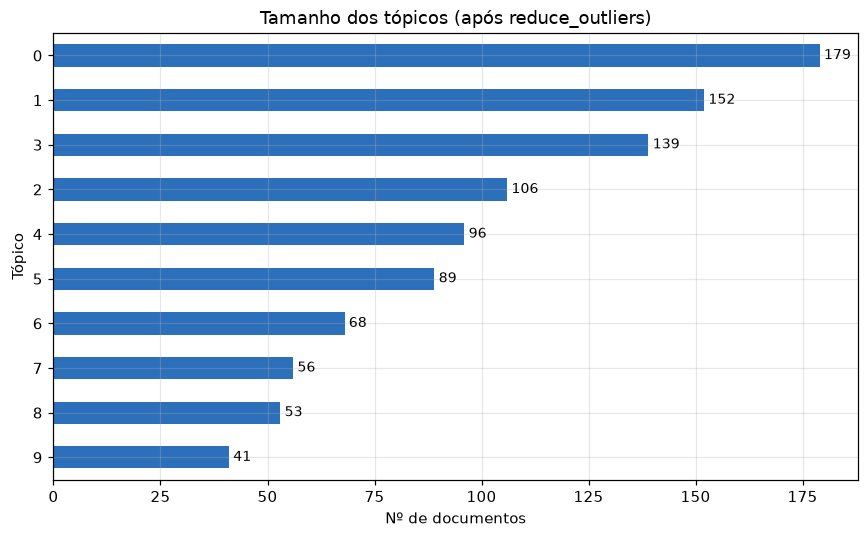

In [4]:
sizes = tbl.sort_values("Nº docs")
ax = sizes.plot(kind="barh", x="Tópico", y="Nº docs", legend=False,
                color="#2c6fbb", figsize=(8, 5))
ax.set_xlabel("Nº de documentos"); ax.set_ylabel("Tópico")
ax.set_title("Tamanho dos tópicos (após reduce_outliers)")
for i, v in enumerate(sizes["Nº docs"]):
    ax.text(v + 1, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "08_topic_sizes.png"); plt.show()

## 3. Termos mais característicos por tópico (c-TF-IDF)

/home/zeca/mestrado/git/cnj-pauta-pln/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


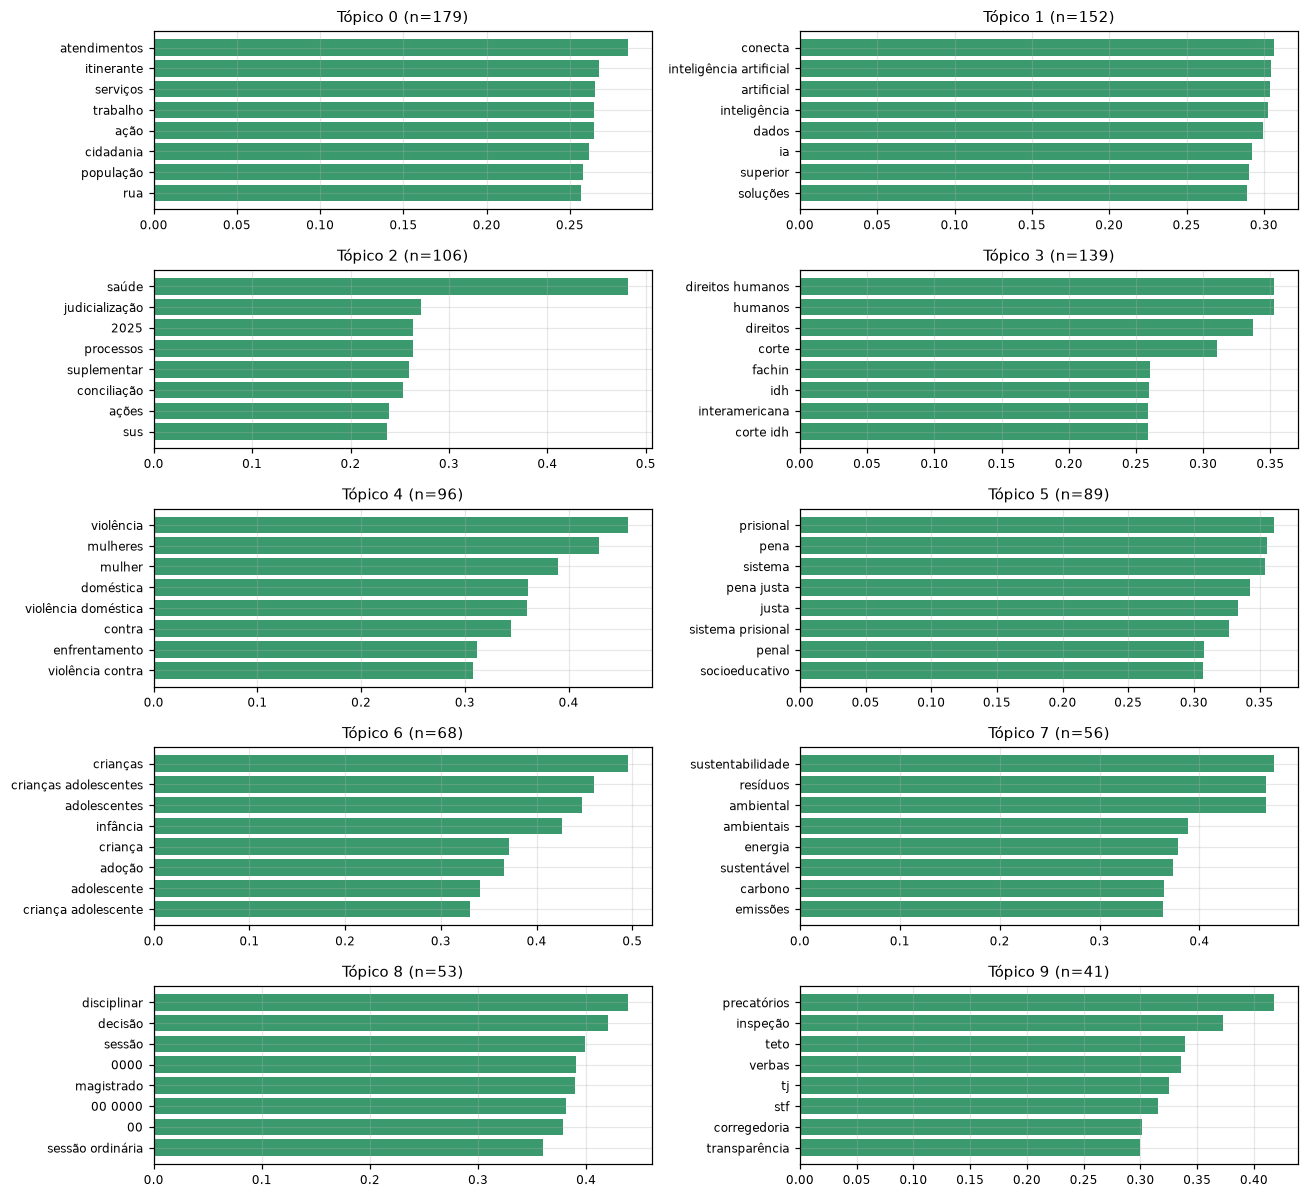

In [5]:
from bertopic import BERTopic
model = BERTopic.load(str(PROC / "bertopic_model"))
tids = sorted(t for t in doc_topics["topic"].unique() if t != -1)
n = len(tids); ncol = 2; nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 2.2 * nrow))
axes = axes.flatten()
for ax, t in zip(axes, tids):
    words = model.get_topic(t)[:8][::-1]
    labels = [w for w, _ in words]; scores = [s for _, s in words]
    ax.barh(labels, scores, color="#3a9a6d")
    ax.set_title(f"Tópico {t} (n={int((doc_topics['topic']==t).sum())})",
                 fontsize=10)
    ax.tick_params(labelsize=8)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout(); plt.savefig(FIG / "09_topic_terms.png"); plt.show()

## Síntese da Fase 4

- **Desafio real documentado:** o corpus é semanticamente homogêneo (cosseno
  médio entre documentos ≈ 0,69, registro institucional). Com o HDBSCAN padrão
  (`eom`), tudo colapsava em **2 tópicos**. A solução foi enfatizar estrutura
  local (`UMAP n_neighbors=10`) e usar `cluster_selection_method="leaf"`.
- **Resultado:** o modelo selecionado (maior c_v) tem **10 tópicos coesos**
  (c_v=0,78; diversidade=1,0), interpretáveis e alinhados à pauta do CNJ.
- **Outliers:** 29% brutos (qualidade do clustering, reportada honestamente),
  reduzidos a 0 via `reduce_outliers` para a análise temporal da Fase 5.
- Configurações com mais granularidade (`min_topic_size=15` → 12 tópicos,
  c_v=0,72) existem; mantivemos o critério declarado (máx. c_v).

Todos os números vêm da execução real de `src/embed.py` + `src/topics.py`
(ver `data/processed/topic_eval.csv`).